# Does cross-attention localise the class?

Text-driven Stable Diffusion comes with a well-known interpretability handle: DAAM.
The prompt is a sequence of tokens, the token "cat" attends to the pixels that become
a cat, and the cross-attention map of that single token draws a segmentation of the
concept it names.

This generator has no tokens. The `ClassEncoder` maps a one-hot vector to a hundred
context slots in a single block — there is no "ears" slot and no "cat" slot, only a
global vector that happens to be shaped like a sequence.

This notebook asks whether cross-attention localises the class anyway. It does not,
and the answer rests on three measurements:

1. the aggregated maps are almost uniform;
2. individual heads *are* selective, but they follow image detail and brightness;
3. that following is identical with and without conditioning, so it carries no class
   information.

A negative result is worth only as much as the effort spent trying to make it
positive. Each step below therefore looks where localisation would be easiest to
find, not where it is easiest to rule out.

The artefacts come from `scripts/xai_test_capture.py` and
`scripts/xai_test_stability.py`. This notebook needs no GPU.

In [2]:
%matplotlib inline

import os
import sys

# The project's code uses paths relative to the repository root. The check keeps
# the cell idempotent when re-run.
if os.path.basename(os.getcwd()) == "Notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from scripts.generator_part.conditioning.lib import common

EXP, DATASET = "xAI", "cifar10"

ATTENTION = common.results_dir(EXP, DATASET, "attention")
uniformity = np.load(os.path.join(ATTENTION, "uniformity.npz"))
stability = np.load(os.path.join(ATTENTION, "stability.npz"))

SIDES = sorted({int(k.rsplit("_", 1)[1])
                for k in uniformity.files if "_condmap_" in k}, reverse=True)

print("attention resolutions :", "  ".join(f"{s}x{s}" for s in SIDES))
print("(layer, head) pairs   :", stability["slot_cv"].size)
print("images                :", stability["images"].shape)
print("stored steps          : first t={}, last t={}".format(
    uniformity["first_timestep"], uniformity["last_timestep"]))

attention resolutions : 16x16  8x8  4x4  2x2
(layer, head) pairs   : 128
images                : (8, 128, 128, 3)
stored steps          : first t=951, last t=1


## 1. The aggregated maps are almost uniform

The softmax runs over the context slots, so at every spatial position the attention is
a distribution summing to one. Averaging it over slots therefore returns a constant
map — it cannot show anything, however suggestive it looks. What *can* vary in space
is how much the class changes that distribution: the total-variation distance between
the conditional and the unconditional pass, position by position. Zero where the class
leaves the reading untouched, one where it redirects it entirely.

The UNet attends at four resolutions. The diffusion model refuses anything below
128×128, so a 32×32 CIFAR target is generated at 128 and downsampled afterwards; the
latent is 16×16 and the attention blocks operate at 16², 8², 4² and 2². The coarsest
one has four positions — whatever localisation means, it does not mean much there.

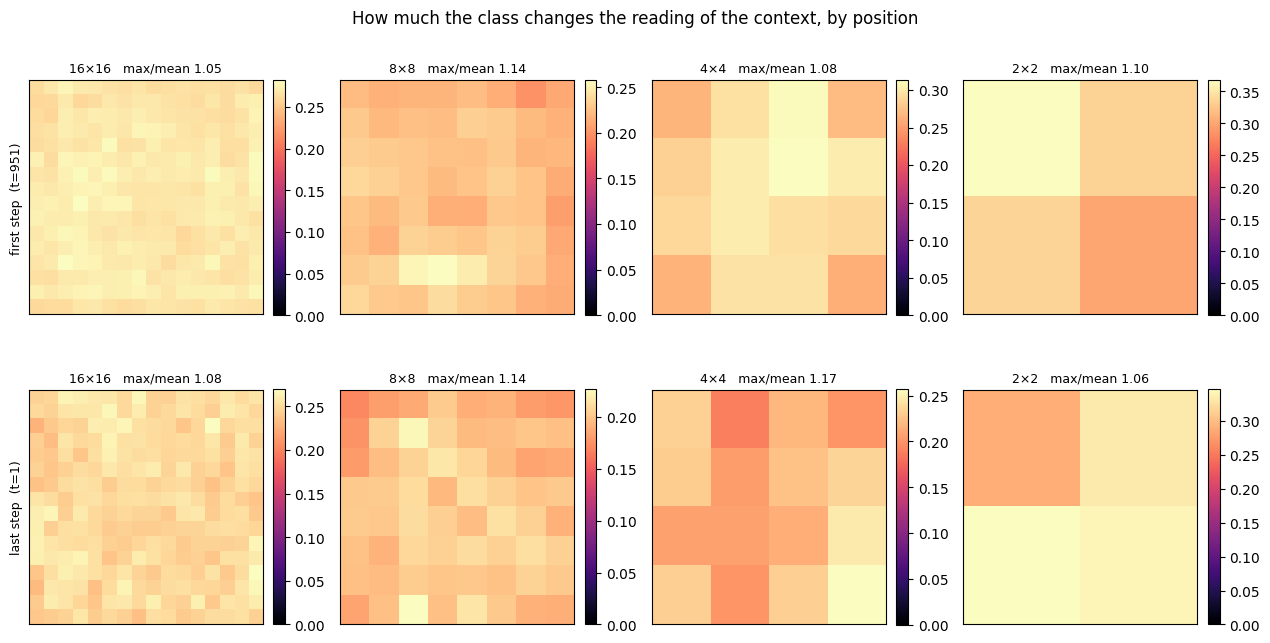

max/mean over all resolutions and both steps: 1.05 to 1.17


In [3]:
fig, axes = plt.subplots(2, len(SIDES), figsize=(3.2 * len(SIDES), 6.8))

for row, tag in enumerate(("first", "last")):
    for col, side in enumerate(SIDES):
        grid = uniformity[f"{tag}_condmap_{side}"]
        ax = axes[row, col]
        # Anchored at zero on purpose: a colour scale stretched to the data would
        # turn a three-per-cent ripple into a vivid pattern and manufacture exactly
        # the localisation this notebook is testing for.
        im = ax.imshow(grid, cmap="magma", vmin=0, vmax=grid.max())
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{side}×{side}   max/mean {grid.max() / grid.mean():.2f}",
                     fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[row, 0].set_ylabel(f"{tag} step  (t={uniformity[f'{tag}_timestep']})",
                            fontsize=9)

fig.suptitle("How much the class changes the reading of the context, by position")
fig.tight_layout()
plt.show()

ratios = [uniformity[f"{t}_condmap_{s}"].max() / uniformity[f"{t}_condmap_{s}"].mean()
          for t in ("first", "last") for s in SIDES]
print(f"max/mean over all resolutions and both steps: "
      f"{min(ratios):.2f} to {max(ratios):.2f}")

The ratio between the most affected position and the average one stays close to 1 at
every resolution and at both ends of denoising. There is no region the class redirects
and no region it leaves alone.

Read the colour bars, though, before concluding that nothing happens: the distance
itself sits around 0.25–0.30 everywhere. The class changes how the context is read by
roughly a quarter of the whole distribution — a large effect, applied uniformly. The
claim of this notebook is not that conditioning is weak. It is that conditioning has
no spatial structure, which is a different statement, and the one consistent with
Result 3, where the same conditioning is shown to decide class identity.

Note also that the colour scale is anchored at zero rather than stretched to each
map's range. Autoscaling would have produced eight vivid patterns from these same
numbers — which is the usual way a negative result gets quietly turned into a
positive one.

## 2. Individual heads are selective — but what do they follow?

An aggregated map can hide structure rather than reveal its absence: if one head
attends to the top-left and another to the bottom-right, their mean is flat while both
are sharply selective. So the second measurement keeps every head separate — 128
(layer, head) pairs, no averaging.

For each of them we take the map of the slot it attends to most. Unlike the
distribution over slots, this map is *not* normalised across space — the softmax runs
over slots, not over positions — so it is free to concentrate anywhere it likes. This
is the DAAM-style quantity. If localisation exists anywhere in this model, it is here.

Selectivity alone is not enough, though. A head whose map never changes from one image
to the next is not looking at content; it is a fixed positional pattern, and the
correlation of its map across the eight generated images tells the two apart.

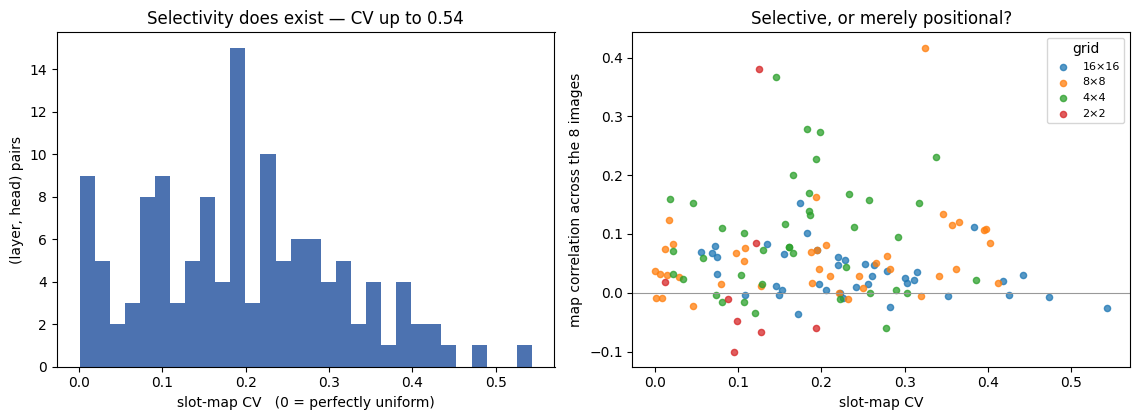

heads: 128   CV median 0.19, max 0.54
correlation across images: median +0.040, min -0.100, max +0.417
most selective head: L13 H4 slot 79 at 16×16, CV 0.54, correlation across images -0.026


In [4]:
slot_cv = stability["slot_cv"]
across = stability["across"]
sides = stability["side"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax1.hist(slot_cv, bins=30, color="#4c72b0")
ax1.set_xlabel("slot-map CV   (0 = perfectly uniform)")
ax1.set_ylabel("(layer, head) pairs")
ax1.set_title(f"Selectivity does exist — CV up to {slot_cv.max():.2f}")

for side in sorted(set(sides.tolist()), reverse=True):
    keep = sides == side
    ax2.scatter(slot_cv[keep], across[keep], s=20, alpha=0.75, label=f"{side}×{side}")
ax2.axhline(0.0, color="0.6", lw=0.8)
ax2.set_xlabel("slot-map CV")
ax2.set_ylabel("map correlation across the 8 images")
ax2.set_title("Selective, or merely positional?")
ax2.legend(title="grid", fontsize=8)

fig.tight_layout()
plt.show()

best = int(stability["best_index"])
print(f"heads: {slot_cv.size}   CV median {np.median(slot_cv):.2f}, max {slot_cv.max():.2f}")
print(f"correlation across images: median {np.median(across):+.3f}, "
      f"min {across.min():+.3f}, max {across.max():+.3f}")
print(f"most selective head: L{stability['layer'][best]} H{stability['head'][best]} "
      f"slot {stability['slot'][best]} at {stability['side'][best]}×{stability['side'][best]}, "
      f"CV {slot_cv[best]:.2f}, correlation across images {across[best]:+.3f}")

Two things come out of that scatter.

**The selectivity is real, and it is not positional.** The CV reaches 0.54, while the
correlation of a head's map across the eight images sits near zero — median +0.04, and
−0.03 for the most selective head of all. A head whose map were a fixed grid pattern
would correlate near +1 from one image to the next; these do not. Whatever they
respond to, they respond to something in the picture.

**But this is the last denoising step**, when the latent finally holds an image. The
same measurement at the first step, when it holds nothing but noise, is next.

Near-zero correlation across images is also consistent with two very different
stories: a map that follows the content, and a map that is simply noise. Separating
them is what the rest of the notebook does.

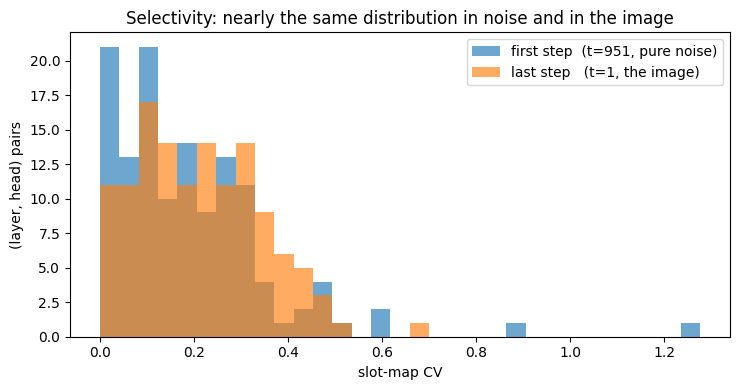

first step (t=951): median 0.16, 90th pct 0.35, max 1.28
 last step (t=  1): median 0.20, 90th pct 0.39, max 0.66


In [5]:
first_cv = uniformity["first_slot_cv"]
last_cv = uniformity["last_slot_cv"]

fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.linspace(0, max(first_cv.max(), last_cv.max()), 32)
ax.hist(first_cv, bins=bins, alpha=0.65,
        label=f"first step  (t={uniformity['first_timestep']}, pure noise)")
ax.hist(last_cv, bins=bins, alpha=0.65,
        label=f"last step   (t={uniformity['last_timestep']}, the image)")
ax.set_xlabel("slot-map CV")
ax.set_ylabel("(layer, head) pairs")
ax.set_title("Selectivity: nearly the same distribution in noise and in the image")
ax.legend()
fig.tight_layout()
plt.show()

for tag in ("first", "last"):
    cv = uniformity[f"{tag}_slot_cv"]
    print(f"{tag:>5} step (t={int(uniformity[f'{tag}_timestep']):>3}): median "
          f"{np.median(cv):.2f}, 90th pct {np.percentile(cv, 90):.2f}, max {cv.max():.2f}")

The two distributions overlap almost entirely — if anything the bulk is slightly
higher at the last step (median 0.20 against 0.16). What separates them is the extreme
tail: the single sharpest head in the whole model, CV 1.28, occurs at t=951, when the
latent is indistinguishable from noise and there is no cat, no sky and no subject to
attend to. That head is precisely the exhibit a DAAM-style analysis would put on the
first slide, and it peaks in the absence of any content to localise.

(This is the measurement `Results/docs/results.md` quotes as "CV up to 1.28". It comes from
`scripts/xai_test_capture.py`, one image, first step. The 0.54 of the previous cell is
the last step over a batch of eight — the same quantity at the other end of denoising,
not a contradiction.)

## 3. Detail, brightness — and does the class change any of it?

If the maps follow content, which content? Local detail is a crude proxy for where
the subject is: in CIFAR the subject is textured and the background largely flat.
Brightness is its confound — a dark subject on a light background produces both — so
a map correlating with one may simply be tracking the other, and both must be measured.

Then the question that decides everything. Every quantity so far describes the
*conditional* pass. Run the same measurement on the *unconditional* one, where no
class is supplied at all. If a head follows detail just as closely without a class as
with one, then what it follows is a property of the UNet's cross-attention, and the
class conditioning has nothing to do with it.

                     median     mean      min      max  best head
       detail cond   -0.051   -0.061   -0.552    0.414     -0.428
     detail uncond   -0.073   -0.089   -0.569    0.409     -0.382
    luminance cond    0.001   -0.006   -0.607    0.359     -0.087
  luminance uncond    0.011   -0.003   -0.687    0.405     -0.062


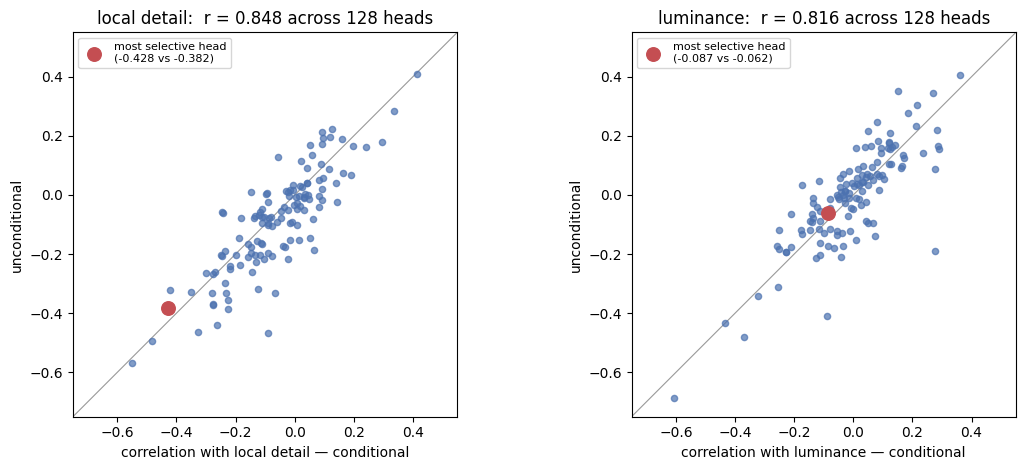

In [6]:
detail_c, detail_u = stability["detail_cond"], stability["detail_uncond"]
lumin_c, lumin_u = stability["lumin_cond"], stability["lumin_uncond"]

print(f"{'':>18}{'median':>9}{'mean':>9}{'min':>9}{'max':>9}{'best head':>11}")
for name, values in (("detail cond", detail_c), ("detail uncond", detail_u),
                     ("luminance cond", lumin_c), ("luminance uncond", lumin_u)):
    print(f"{name:>18}{np.median(values):>9.3f}{values.mean():>9.3f}"
          f"{values.min():>9.3f}{values.max():>9.3f}{values[best]:>11.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
limits = [-0.75, 0.55]

for ax, (cond, uncond, what) in zip(axes, ((detail_c, detail_u, "local detail"),
                                           (lumin_c, lumin_u, "luminance"))):
    ax.plot(limits, limits, color="0.6", lw=0.8, zorder=0)
    ax.scatter(cond, uncond, s=20, alpha=0.7, color="#4c72b0")
    ax.scatter(cond[best], uncond[best], s=95, color="#c44e52", zorder=3,
               label=f"most selective head\n({cond[best]:+.3f} vs {uncond[best]:+.3f})")
    ax.set_xlim(limits); ax.set_ylim(limits); ax.set_aspect("equal")
    ax.set_xlabel(f"correlation with {what} — conditional")
    ax.set_ylabel("unconditional")
    ax.set_title(f"{what}:  r = {np.corrcoef(cond, uncond)[0, 1]:.3f} across {cond.size} heads")
    ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

Both panels put the heads on the diagonal. Across all 128 of them, the per-head profile
of detail-following is nearly the same whether a class is supplied or not — r = 0.85
for detail, r = 0.82 for luminance. The most selective head of all (in red) sits on the
line too: −0.428 conditional against −0.382 unconditional.

Whatever these heads are doing, they do just as well with no class at all. It is a
property of the UNet's cross-attention, inherited from the pre-trained model, and not
a trace of the class conditioning.

Two details are worth keeping:

- **the correlation with detail is negative.** The sharpest head in the model attends
  *away* from the textured regions, onto the flat background. Read as a localisation
  of the class, it would be pointing at everything the class is not.
- **brightness is not the explanation.** For that head the luminance correlation is
  −0.087 against −0.428 for detail. The confound was worth measuring, and it does not
  account for what we see.

Not every head is identical across the two passes — the largest single gap is 0.376,
so conditioning is not literally invisible to attention. The claim is the one the
numbers actually support: there is no systematic difference, and no head whose
behaviour depends on the class in the way localisation would require.

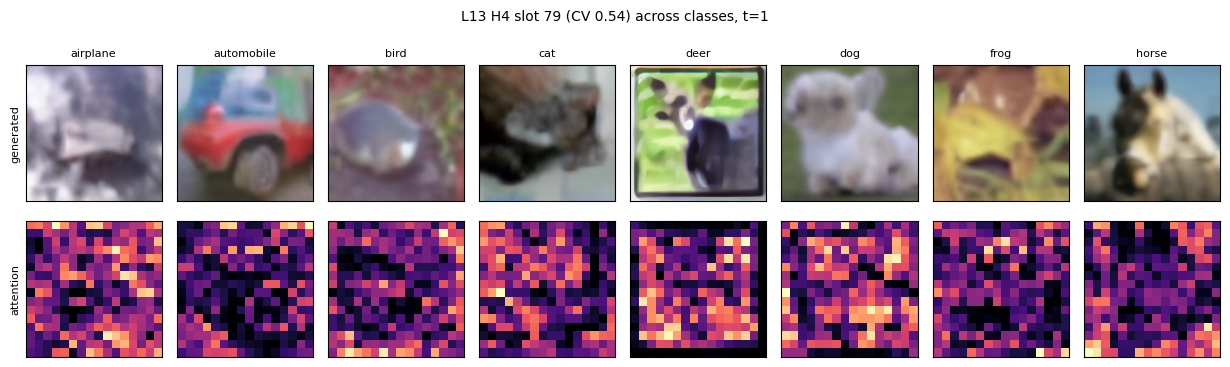

In [7]:
maps, images, labels = (stability["best_maps"], stability["images"],
                        stability["labels"])

fig, axes = plt.subplots(2, len(images), figsize=(1.55 * len(images), 3.9))
for i in range(len(images)):
    axes[0, i].imshow(images[i])
    axes[0, i].set_title(labels[i], fontsize=8)
    # Autoscaled here, unlike cell 4: stretching the contrast shows this map at its
    # most structured, which is the harder case for the claim being made.
    axes[1, i].imshow(maps[i], cmap="magma")
    for ax in (axes[0, i], axes[1, i]):
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("generated", fontsize=8)
axes[1, 0].set_ylabel("attention", fontsize=8)

fig.suptitle(f"L{stability['layer'][best]} H{stability['head'][best]} "
             f"slot {stability['slot'][best]} (CV {stability['slot_cv'][best]:.2f}) "
             f"across classes, t={stability['timestep']}", fontsize=10)
fig.tight_layout()
plt.show()

This is the most selective head in the batch, at the step where the latent holds the
finished image: the single best chance this model has of producing a DAAM-style map.

What it produces is speckle. The structure sits at the scale of one cell of the 16×16
grid, scattered, with no contiguous region anywhere. The cat, the dog and the horse are
plainly visible in the row above; nothing in the row below traces any of them. And the
maps do change from image to image, exactly as the near-zero correlation across images
said — so this is not one fixed pattern being reused, it is a different speckle each
time.

The one map with visible large-scale structure is the deer, and the deer is the one
generated image with a large flat border. The exception follows a property of the
image, not of the class — the same finding, reached from a different direction.

## A by-product: ten slots out of a hundred

The measurements above need the attention each context slot receives, and that quantity
says something on its own. The `ClassEncoder` emits a hundred slots because the UNet's
cross-attention expects a context of that length — nothing in training required all
hundred to carry information.

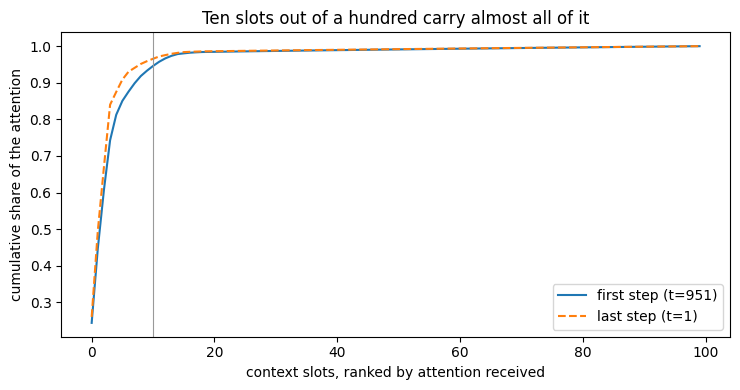

first step: top-10 slots hold 93.3% of the attention; most attended [4, 3, 61, 94, 6, 97, 95, 2]
 last step: top-10 slots hold 95.9% of the attention; most attended [4, 3, 61, 94, 97, 6, 2, 79]


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))

for tag, style in (("first", "-"), ("last", "--")):
    weights = uniformity[f"{tag}_token_weights"].mean(axis=0)
    ax.plot(np.sort(weights)[::-1].cumsum(), style,
            label=f"{tag} step (t={uniformity[f'{tag}_timestep']})")

ax.axvline(10, color="0.6", lw=0.8)
ax.set_xlabel("context slots, ranked by attention received")
ax.set_ylabel("cumulative share of the attention")
ax.set_title("Ten slots out of a hundred carry almost all of it")
ax.legend()
fig.tight_layout()
plt.show()

for tag in ("first", "last"):
    weights = uniformity[f"{tag}_token_weights"].mean(axis=0)
    order = np.argsort(weights)[::-1]
    print(f"{tag:>5} step: top-10 slots hold {weights[order[:10]].sum():.1%} of the "
          f"attention; most attended {order[:8].tolist()}")

Ten slots out of a hundred receive 93–96% of the attention — and the single most
attended slot takes about a quarter of it on its own. They are largely the same ten at
both ends of denoising: the context the UNet is handed is nominally a sequence of a
hundred positions, and the ten that matter are fixed from the first step to the last.

## Why it had to come out this way

The `ClassEncoder` maps a one-hot vector through dense layers into a hundred context
slots, all at once. Nothing in that architecture makes one slot mean "ears" and another
mean "fur": the slots exist because the cross-attention expects that context length,
and they are produced together from a single input. In text-driven Stable Diffusion the
token "cat" is a token *because* the prompt is a sequence of independent positions, and
DAAM works by asking where that one position is read. Here there is no position to
isolate. The conditioning is a global vector wearing the shape of a sequence.

So this is not a failed measurement, nor a quirk of one checkpoint. It is the direct
consequence of the geometry measured in [01_conditioning](01_conditioning.ipynb): a
space where classes sit as whole points rather than as compositions of parts. A global
vector has nothing to localise.

**What this rules out, and what it leaves open.** Cross-attention is not the route to
explaining this generator, and the DAAM-shaped question was the wrong question to ask
of it. That says nothing about *whether* the conditioning works — it plainly does — nor
about *when* it acts, which is what [03_temporal](03_temporal.ipynb) measures, and where
the answer turns out to be worth the trouble.